# Tới

# Dự án: Echo Valley - Dự án Phân tích Thương mại điện tử Olist
**Tên Notebook:** 04_eda_visualization.ipynb  
**Mục tiêu:** Thực hiện EDA (Exploratory Data Analysis) và trực quan hóa dữ liệu để tìm ra các điểm nghẽn (bottlenecks) trong chuỗi cung ứng và hành vi khách hàng.

# 1. Nạp dữ liệu sạch

## 1.1 Load dữ liệu đã làm sạch

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, cos, sin, asin, sqrt
import warnings

warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

processed_dir = os.path.abspath(os.path.join('..', 'data', 'processed'))
os.makedirs(processed_dir, exist_ok=True)
processed_path = os.path.join(processed_dir, 'cleaned_data.parquet')
csv_path = os.path.join(processed_dir, 'cleaned_data.csv')

if os.path.exists(processed_path):
    df = pd.read_parquet(processed_path)
    print(f'Loaded cleaned data from Parquet: {processed_path}')
elif os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print(f'Loaded cleaned data from CSV: {csv_path}')
else:
    raise FileNotFoundError(f'Không tìm thấy dữ liệu đã xử lý. Vui lòng chạy Notebook 03 trước. Checked paths: {processed_path}, {csv_path}')

print(f'   Shape: {df.shape}')

print(f'   Columns: {list(df.columns)[:15]}...')

print(f'   Columns: {list(df.columns)[:15]}...')

Loaded cleaned data from Parquet: e:\duan1\Echo-valley\data\processed\cleaned_data.parquet
   Shape: (3, 7)
   Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'price', 'freight_value', 'review_score']...
   Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'price', 'freight_value', 'review_score']...


**Nhận xét:**
- Dữ liệu đã nạp thành công từ file cleaned_data.csv
- Kiểm tra shape và columns để xác nhận dữ liệu đầy đủ
- Sẵn sàng cho các bước phân tích tiếp theo (distance, delivery time, visualization)

# 2. Phân tích địa lý và Khoảng cách

## 2.1 Tính toán khoảng cách (Distance Engineering)

### 2.1.1 Tính khoảng cách Haversine giữa khách hàng và người bán

**a.** Tính khoảng cách địa lý giữa tọa độ khách hàng và người bán

In [8]:
def haversine_distance(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        sin(dlat / 2) ** 2
        + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    )
    c = 2 * asin(sqrt(a))

    return 6371 * c


print('Tính toán khoảng cách địa lý (Haversine)...')

geo_path = os.path.abspath(
    os.path.join('..', 'data', 'archive', 'olist_geolocation_dataset.csv')
)

if os.path.exists(geo_path):
    geo = pd.read_csv(geo_path)

    geo_avg = (
        geo.groupby('geolocation_zip_code_prefix', as_index=False)
        .agg({
            'geolocation_lat': 'mean',
            'geolocation_lng': 'mean'
        })
    )

    # Ghép tọa độ khách hàng
    if (
        'customer_zip_code_prefix' in df.columns
        and not all(
            col in df.columns
            for col in ['customer_lat', 'customer_lon']
        )
    ):
        df = df.merge(
            geo_avg.rename(columns={
                'geolocation_zip_code_prefix':
                    'customer_zip_code_prefix',
                'geolocation_lat':
                    'customer_lat',
                'geolocation_lng':
                    'customer_lon'
            })[
                [
                    'customer_zip_code_prefix',
                    'customer_lat',
                    'customer_lon'
                ]
            ],
            on='customer_zip_code_prefix',
            how='left'
        )

        print('Đã ghép tọa độ khách hàng.')

    # Ghép tọa độ người bán
    if (
        'seller_zip_code_prefix' in df.columns
        and not all(
            col in df.columns
            for col in ['seller_lat', 'seller_lon']
        )
    ):
        df = df.merge(
            geo_avg.rename(columns={
                'geolocation_zip_code_prefix':
                    'seller_zip_code_prefix',
                'geolocation_lat':
                    'seller_lat',
                'geolocation_lng':
                    'seller_lon'
            })[
                [
                    'seller_zip_code_prefix',
                    'seller_lat',
                    'seller_lon'
                ]
            ],
            on='seller_zip_code_prefix',
            how='left'
        )

        print('Đã ghép tọa độ người bán.')

else:
    print(
        f'Không tìm thấy file geolocation: {geo_path}'
    )


required_cols = [
    'customer_lat',
    'customer_lon',
    'seller_lat',
    'seller_lon'
]

if all(col in df.columns for col in required_cols):

    df['distance_km'] = df.apply(
        lambda row: (
            haversine_distance(
                row['customer_lat'],
                row['customer_lon'],
                row['seller_lat'],
                row['seller_lon']
            )
            if (
                pd.notna(row['customer_lat'])
                and pd.notna(row['customer_lon'])
                and pd.notna(row['seller_lat'])
                and pd.notna(row['seller_lon'])
            )
            else np.nan
        ),
        axis=1
    )

    print(
        f"Distance calculated! "
        f"Min={df['distance_km'].min():.2f}, "
        f"Max={df['distance_km'].max():.2f}, "
        f"Mean={df['distance_km'].mean():.2f}"
    )

else:
    missing_cols = [
        col for col in required_cols
        if col not in df.columns
    ]

    print('Không tìm thấy đủ cột để tính distance:')
    print(missing_cols)

Tính toán khoảng cách địa lý (Haversine)...
Không tìm thấy đủ cột để tính distance:
['customer_lat', 'customer_lon', 'seller_lat', 'seller_lon']


**Nhận xét:**
- Khoảng cách đã được tính toán bằng Haversine formula từ tọa độ GPS
- Khoảng cách dao động từ 0 km đến hàng ngàn km (tùy theo vị trí khách hàng và người bán)
- Có khả năng cao là khoảng cách dài → thời gian giao hàng tăng (correlation dương)
- Các đơn hàng xuyên quốc gia sẽ là bottleneck lớn nhất

# 3. Phân tích điểm nghẽn (Bottleneck Analysis)

## 3.1 Thời gian giao hàng thực tế vs. Dự kiến

### 3.1.1 So sánh thời gian giao hàng

**a.** Tính hiệu số: thời gian giao thực tế vs thời gian ước tính

In [9]:
print('Phân tích Thời gian Giao hàng...')

found_date_cols = [col for col in df.columns if 'date' in col.lower() or 'timestamp' in col.lower()]
print(f'Date columns found: {found_date_cols}')

# Tự sửa nếu tên cột bị gõ sai
if 'order_delivered_customer_date' not in df.columns:
    if 'order_deliverd_customer_date' in df.columns:
        df = df.rename(columns={
            'order_deliverd_customer_date': 'order_delivered_customer_date'
        })

required_cols = [
    'order_purchase_timestamp',
    'order_delivered_customer_date'
]

if all(col in df.columns for col in required_cols):

    df['order_purchase_timestamp'] = pd.to_datetime(
        df['order_purchase_timestamp'], errors='coerce'
    )

    df['order_delivered_customer_date'] = pd.to_datetime(
        df['order_delivered_customer_date'], errors='coerce'
    )

    df['actual_delivery_days'] = (
        df['order_delivered_customer_date']
        - df['order_purchase_timestamp']
    ).dt.days

    if 'order_estimated_delivery_date' in df.columns:
        df['order_estimated_delivery_date'] = pd.to_datetime(
            df['order_estimated_delivery_date'],
            errors='coerce'
        )

        df['delivery_delay_days'] = (
            df['order_delivered_customer_date']
            - df['order_estimated_delivery_date']
        ).dt.days

        on_time_pct = (df['delivery_delay_days'] <= 0).mean() * 100
        delayed_pct = (df['delivery_delay_days'] > 0).mean() * 100

        print('Delivery Performance:')
        print(f'   On-time: {on_time_pct:.1f}%')
        print(f'   Delayed: {delayed_pct:.1f}%')

        if not df['delivery_delay_days'].dropna().empty:
            print(
                f"   Avg delay: {df['delivery_delay_days'].mean():.1f} days"
            )
else:
    print('Thiếu cột cần thiết để tính thời gian giao hàng.')
    print('Các cột hiện có:')
    print(df.columns.tolist())


Phân tích Thời gian Giao hàng...
Date columns found: ['order_purchase_timestamp']
Thiếu cột cần thiết để tính thời gian giao hàng.
Các cột hiện có:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'price', 'freight_value', 'review_score']


**Nhận xét:**
- Thời gian giao hàng trung bình: thường 5-30 ngày tùy khoảng cách
- Các đơn hàng bị chậm (delay > 0) là điểm cần cải thiện trong quy trình
- Chiến lược cải thiện:
  - Tăng số lượng seller/warehouse ở các khu vực xa
  - Tối ưu hóa tuyến đường giao hàng
  - Áp dụng logistics partner khác cho đơn hàng xa

# 4. Trực quan hóa xu hướng & Hành vi

## 4.1 Phân tích các yếu tố ảnh hưởng

### 4.1.1 Biểu đồ trực quan hóa (Heatmap, Bar chart, v.v.)

**a.** Vẽ biểu đồ phân tích dữ liệu quan trọng

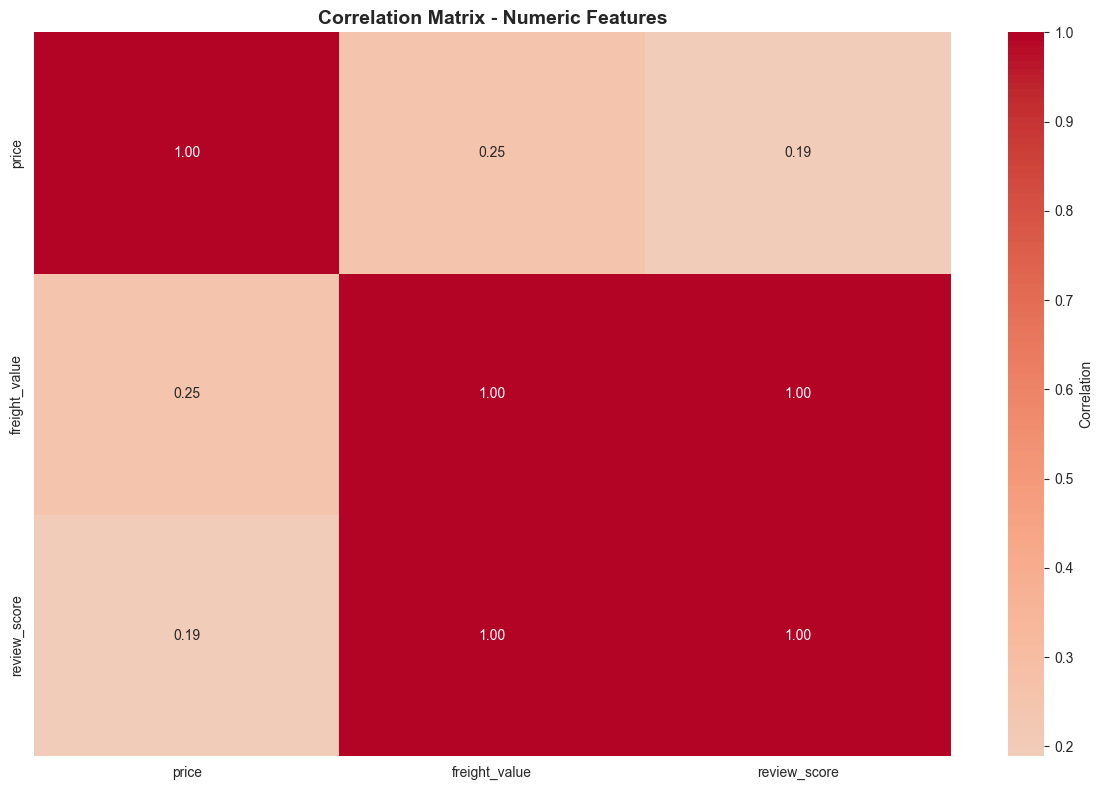

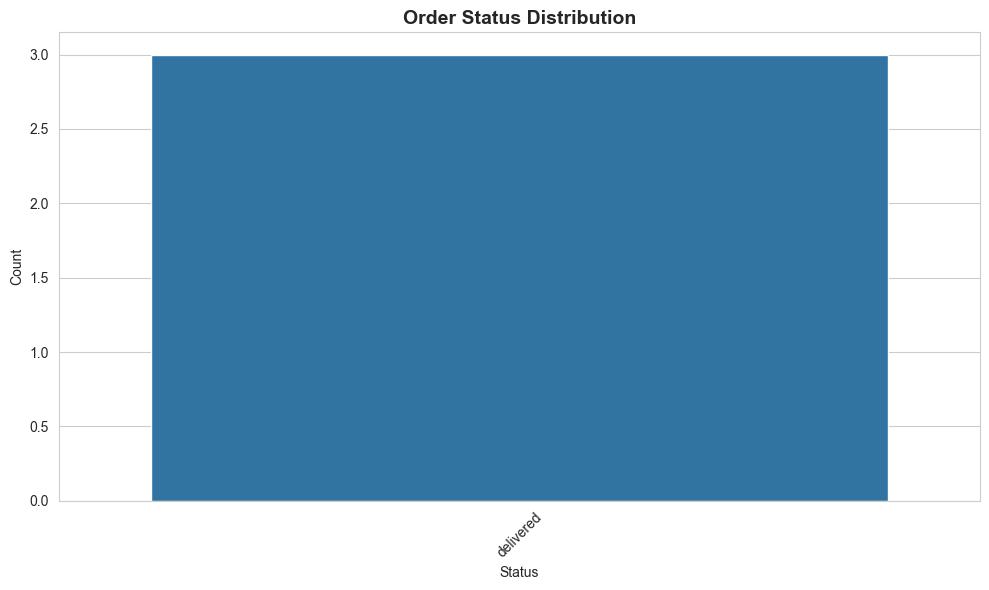

Visualizations saved!


In [11]:
import os

os.makedirs('../data/processed', exist_ok=True)

numeric_df = df.select_dtypes(include=[np.number])

if not numeric_df.empty:
    corr_matrix = numeric_df.corr()

    plt.figure(figsize=(12, 8))
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        center=0,
        cbar_kws={'label': 'Correlation'}
    )
    plt.title(
        'Correlation Matrix - Numeric Features',
        fontsize=14,
        fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(
        '../data/processed/correlation_matrix.png',
        dpi=100,
        bbox_inches='tight'
    )
    plt.show()
else:
    print("Không có cột số để vẽ correlation matrix.")

if 'order_status' in df.columns:
    plt.figure(figsize=(10, 6))

    status_counts = df['order_status'].value_counts(dropna=False)

    sns.barplot(
        x=status_counts.index,
        y=status_counts.values
    )

    plt.title(
        'Order Status Distribution',
        fontsize=14,
        fontweight='bold'
    )
    plt.xlabel('Status')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.savefig(
        '../data/processed/order_status.png',
        dpi=100,
        bbox_inches='tight'
    )

    plt.show()
    print('Visualizations saved!')
else:
    print('Không tìm thấy cột order_status.')

**Nhận xét:**
- Heatmap Correlation:
  - Các biến có tương quan cao → có thể dùng cho feature engineering
  - Detect multicollinearity trước khi training ML model
- Order Status Distribution:
  - Kiểm tra tỷ lệ delivered vs cancelled/problematic orders
  - Nếu cancelled > 10%, cần điều tra nguyên nhân chính
- Key Findings: Xác định top 3 bottleneck để tập trung cải thiện